In [1]:
from google.colab import files
print("Enter your dataset")
uploaded = files.upload()

Enter your dataset


Saving fake_or_real_news.csv to fake_or_real_news.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score,recall_score,f1_score,confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer


In [3]:
df = pd.read_csv('fake_or_real_news.csv')
print(df.head())

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [4]:
df = df.drop(["Unnamed: 0"] , axis =1)
print(df.head())

                                               title  \
0                       You Can Smell Hillary’s Fear   
1  Watch The Exact Moment Paul Ryan Committed Pol...   
2        Kerry to go to Paris in gesture of sympathy   
3  Bernie supporters on Twitter erupt in anger ag...   
4   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [5]:
df['label'] = df['label'].map({'REAL': 1, 'FAKE': 0})
display(df.head())

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english' , ngram_range = (1,2) , max_df = 0.7)
df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

In [24]:
df['full_text'] = df['title'] + ' ' + df['text']
words = tfidf.fit_transform(df['full_text'])
model = LogisticRegression(max_iter=2000)
X_train , X_test , y_train , y_test = train_test_split(words , df['label'] , stratify=df['label'] , test_size = 0.2 , random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [25]:
y_predict = model.predict(X_test)

In [26]:
Accuracy = accuracy_score(y_test , y_predict)*100
print('Accuracy of model:' , Accuracy)
Recall = recall_score(y_test , y_predict)*100
print('Recall of model:' , Recall)
Precision = precision_score(y_test , y_predict)*100
print('Precision of model:' , Precision)
F1_score = f1_score(y_test , y_predict)*100
print('F1_score of model:' , F1_score)

Accuracy of model: 91.08129439621152
Recall of model: 86.90851735015774
Precision of model: 94.83648881239243
F1_score of model: 90.69958847736626


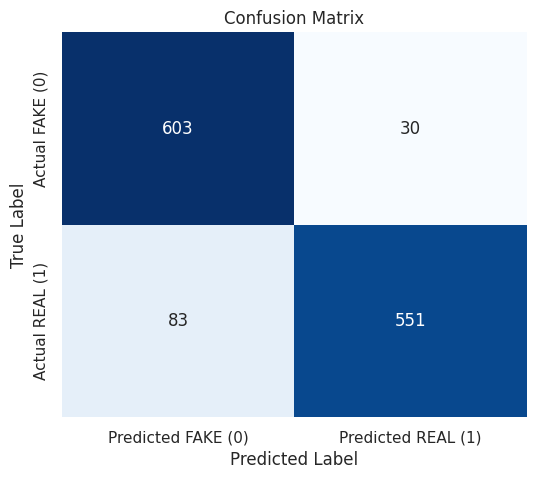

In [49]:
cm = confusion_matrix(y_test, y_predict)
mt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted FAKE (0)', 'Predicted REAL (1)'],
            yticklabels=['Actual FAKE (0)', 'Actual REAL (1)'])
mt.xlabel('Predicted Label')
mt.ylabel('True Label')
mt.title('Confusion Matrix')
mt.show()

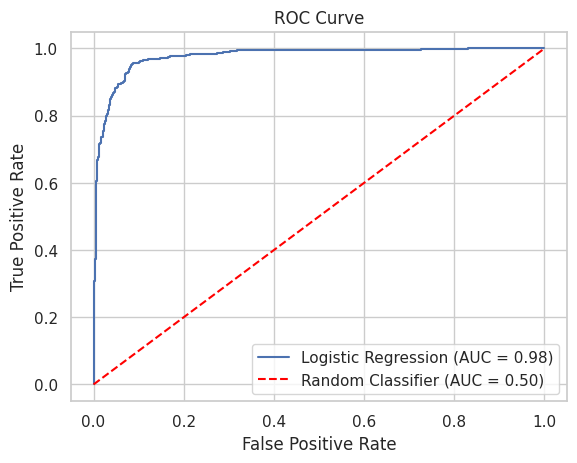

In [45]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

mt.plot(fpr, tpr , label =f"Logistic Regression (AUC = {roc_auc:.2f})")
sns.lineplot(x=[0,1] ,y=[0,1] , linestyle = '--' , color ='red' ,label ='Random Classifier (AUC = 0.50)')
mt.grid('On')
mt.xlabel("False Positive Rate")
mt.ylabel("True Positive Rate")
mt.legend()
mt.title("ROC Curve")
mt.show()

In [46]:
from sklearn.svm import LinearSVC
model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [47]:
predictions = model.predict(X_test)

In [48]:
print("SVM Accuracy:", accuracy_score(y_test, predictions)*100)
print("SVM F1:", f1_score(y_test, predictions)*100)
print("SVM Precision:", precision_score(y_test, predictions)*100)
print("SVM Recall:", recall_score(y_test, predictions)*100)

SVM Accuracy: 94.31728492501973
SVM F1: 94.19354838709677
SVM Precision: 96.36963696369637
SVM Recall: 92.11356466876973


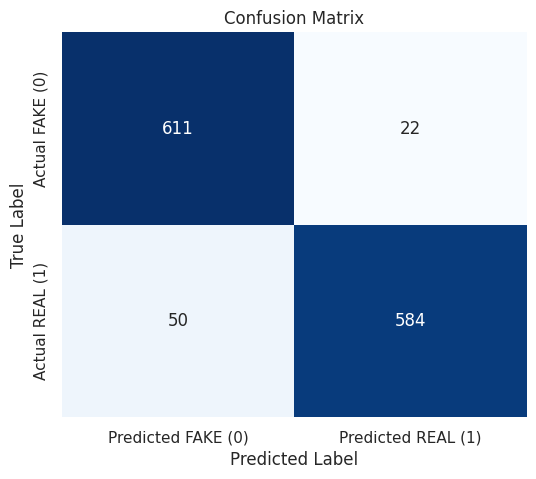

In [53]:
cm = confusion_matrix(y_test, predictions)
mt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted FAKE (0)', 'Predicted REAL (1)'],
            yticklabels=['Actual FAKE (0)', 'Actual REAL (1)'])
mt.xlabel('Predicted Label')
mt.ylabel('True Label')
mt.title('Confusion Matrix')
mt.show()

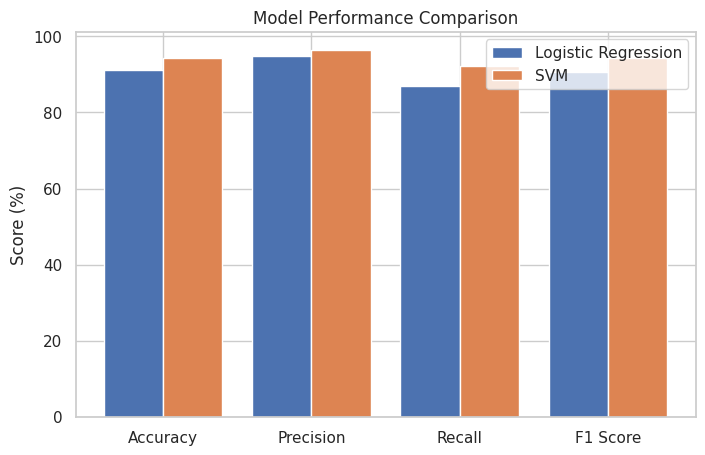

In [60]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr = [91.08, 94.84, 86.91, 90.70]
svc = [94.31, 96.37, 92.11, 94.19]

x = range(len(metrics))
width = 0.4

plt.figure(figsize=(8,5))

plt.bar([i - width/2 for i in x], lr, width, label='Logistic Regression')

plt.bar([i + width/2 for i in x], svc, width, label='SVM')

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()